# MP3 — Performance Notebook
**Course:** Numerical Scientific Computing  
**Environment:** Apple Silicon MacBook Air (M4, 10 logical cores, macOS).
**Default benchmark grid:** N=1024, max_iter=100, region [-2.0, 1.0] × [-1.5, 1.5] (unless stated otherwise)

This notebook collects the results of L08 (numerical accuracy), L09 (testing and documentation) and L10 (GPU acceleration).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

---
## Section 1 — Numerical accuracy

Two diagnostic maps over a small zoom region near the seahorse valley ([-0.7530, -0.7490] × [0.0990, 0.1030]), produced by `mandelbrot_precision.py`:

### 1.1 Trajectory divergence (L08-M1)
**Region:** [-0.7530, -0.7490] × [0.0990, 0.1030] (basically zoom near seahorse valley)  
**Grid:** 512×512  
**Threshold tau:** 0.01
**Iterations cap:** 1000


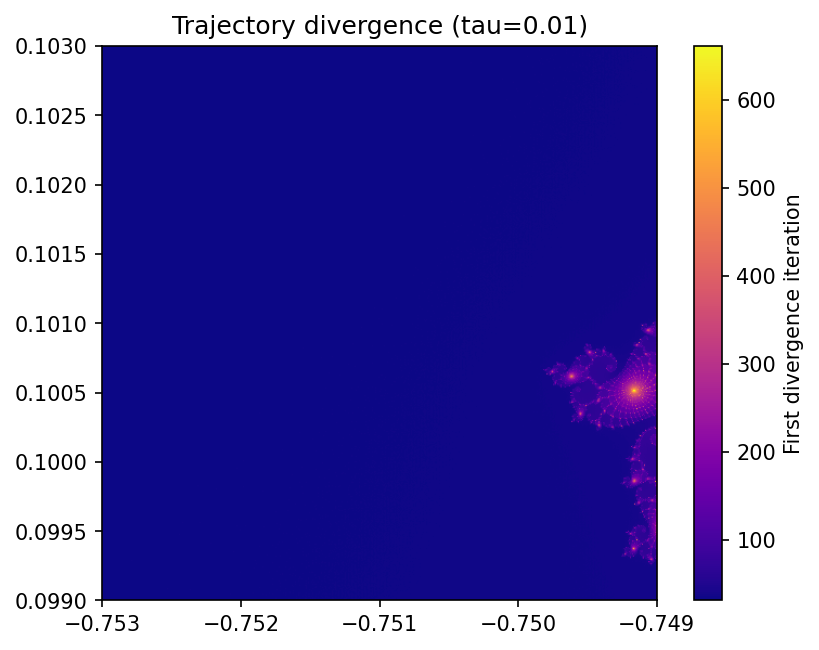

In [2]:
display(Image("trajectory_divergence.png"))

### 1.2 Sensitivity map (L08-M2)
**Region:** [-0.7530, -0.7490] × [0.0990, 0.1030]
**Grid:** 512×512  
**Iterations cap:** 1000


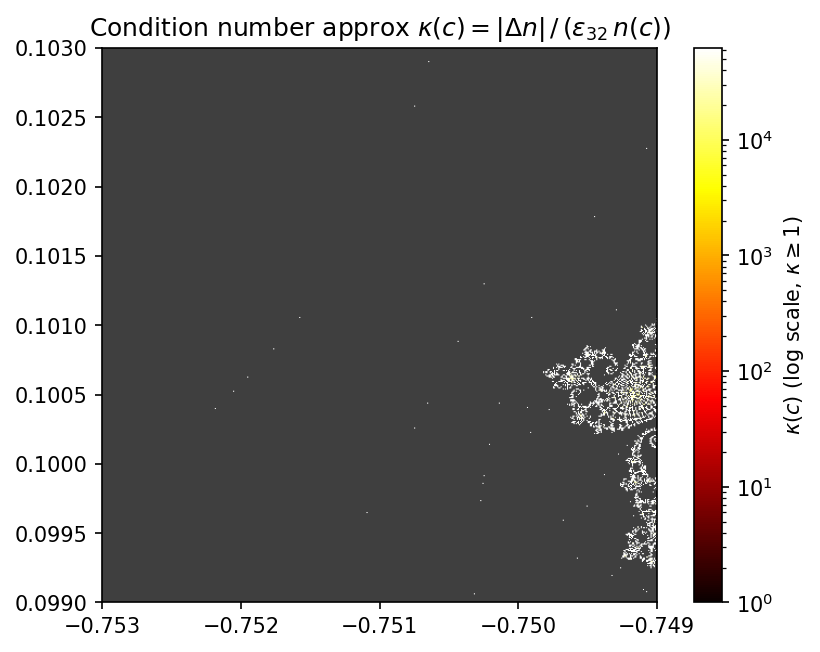

In [3]:
display(Image("sensitivity_map.png"))

### 1.3 Spatial agreement

Both images target the same zoom near the seahorse valley. Inside the body of the set in the dark interior of M1 the two trajectories stay close for the full 1000 iterations. Outside that body, M1 lights up early.

M2 paints the same boundary, but on a more useful axis. The condition number is highest exactly along the filaments where the iteration is *near-marginal*.

So spatially the two maps agree on *where* numerical fragility lives but they answer different questions. M1 says "the f32 and f64 trajectories diverge here quickly," which is a property of the iteration. M2 says "the *output* or escape count is sensitive here," which is what actually matters when picking a working precision for a render.

---
## Section 2 — Testing and documentation

The test suite is done in `test_mandelbrot.py` and exercises the four CPU implementations (naive, NumPy, Numba serial, Numba and multiprocessing) with the same set of fixtures. Documentation pass and `ruff` cleanup were applied to `mandelbrot_parallel.py`.

### 2.1 Test suite — `pytest -v`

In [4]:
print("""============================= test session starts ==============================
platform darwin -- Python 3.11.14, pytest-9.0.2, pluggy-1.6.0 -- /Users/deian/miniforge3/envs/nsc2026/bin/python3.11
cachedir: .pytest_cache
rootdir: /Users/deian/Desktop/deian/aau/second_semester/nsc-course/mandelbrot-nsc
plugins: cov-7.0.0
collected 8 items

test_mandelbrot.py::test_naive_pixel[0j-100-100] PASSED                  [ 12%]
test_mandelbrot.py::test_naive_pixel[(5+0j)-100-0] PASSED                [ 25%]
test_mandelbrot.py::test_naive_pixel[(-3+0j)-100-0] PASSED               [ 37%]
test_mandelbrot.py::test_numba_pixel[0j-100-100] PASSED                  [ 50%]
test_mandelbrot.py::test_numba_pixel[(5+0j)-100-1] PASSED                [ 62%]
test_mandelbrot.py::test_numba_pixel[(-2.5+0j)-100-1] PASSED             [ 75%]
test_mandelbrot.py::test_numpy_matches_naive_on_small_grid PASSED        [ 87%]
test_mandelbrot.py::test_parallel_matches_serial_on_small_grid PASSED    [100%]

============================== 8 passed in 1.64s ===============================""")

============================= test session starts ==============================
platform darwin -- Python 3.11.14, pytest-9.0.2, pluggy-1.6.0 -- /Users/deian/miniforge3/envs/nsc2026/bin/python3.11
cachedir: .pytest_cache
rootdir: /Users/deian/Desktop/deian/aau/second_semester/nsc-course/mandelbrot-nsc
plugins: cov-7.0.0
collected 8 items

test_mandelbrot.py::test_naive_pixel[0j-100-100] PASSED                  [ 12%]
test_mandelbrot.py::test_naive_pixel[(5+0j)-100-0] PASSED                [ 25%]
test_mandelbrot.py::test_naive_pixel[(-3+0j)-100-0] PASSED               [ 37%]
test_mandelbrot.py::test_numba_pixel[0j-100-100] PASSED                  [ 50%]
test_mandelbrot.py::test_numba_pixel[(5+0j)-100-1] PASSED                [ 62%]
test_mandelbrot.py::test_numba_pixel[(-2.5+0j)-100-1] PASSED             [ 75%]
test_mandelbrot.py::test_numpy_matches_naive_on_small_grid PASSED        [ 87%]
test_mandelbrot.py::test_parallel_matches_serial_on_small_grid PASSED    [100%]

=================

### 2.2 Coverage — `pytest --cov`


In [5]:
print("""============================= test session starts ==============================
platform darwin -- Python 3.11.14, pytest-9.0.2, pluggy-1.6.0
rootdir: /Users/deian/Desktop/deian/aau/second_semester/nsc-course/mandelbrot-nsc
plugins: cov-7.0.0
collected 8 items

test_mandelbrot.py ........                                              [100%]

================================ tests coverage ================================
______________ coverage: platform darwin, python 3.11.14-final-0 _______________

Name                      Stmts   Miss  Cover   Missing
-------------------------------------------------------
benchmark.py                 34     34     0%   7-54
dtype_experiment.py          79     79     0%   11-124
mandelbrot_dask.py          123    123     0%   1-159
mandelbrot_gpu.py            55     55     0%   7-171
mandelbrot_naive.py          42     21    50%   58-89, 93
mandelbrot_numba.py          71     71     0%   11-133
mandelbrot_numpy.py          43     21    51%   60-65, 69-87, 91
mandelbrot_parallel.py      132     99    25%   47-55, 91-98, 131, 171, 182, 192-323
mandelbrot_precision.py      52     52     0%   1-58
opencl_template.py           24     24     0%   9-57
profiling.py                 19     19     0%   10-47
test_mandelbrot.py           24      0   100%
-------------------------------------------------------
TOTAL                       698    598    14%
============================== 8 passed in 1.44s ===============================""")

============================= test session starts ==============================
platform darwin -- Python 3.11.14, pytest-9.0.2, pluggy-1.6.0
rootdir: /Users/deian/Desktop/deian/aau/second_semester/nsc-course/mandelbrot-nsc
plugins: cov-7.0.0
collected 8 items

test_mandelbrot.py ........                                              [100%]

================================ tests coverage ================================
______________ coverage: platform darwin, python 3.11.14-final-0 _______________

Name                      Stmts   Miss  Cover   Missing
-------------------------------------------------------
benchmark.py                 34     34     0%   7-54
dtype_experiment.py          79     79     0%   11-124
mandelbrot_dask.py          123    123     0%   1-159
mandelbrot_gpu.py            55     55     0%   7-171
mandelbrot_naive.py          42     21    50%   58-89, 93
mandelbrot_numba.py          71     71     0%   11-133
mandelbrot_numpy.py          43     21    51%   60-6

### 2.3 Documentation pass and `ruff check` (L09-M2)

`mandelbrot_parallel.py` was the file picked for the documentation milestone. Every public function got a NumPy style docstring and full type hints on parameters and return values. After running `ruff format` once and `ruff check`:

In [6]:
print("""$ ruff check mandelbrot_parallel.py
All checks passed!""")

$ ruff check mandelbrot_parallel.py
All checks passed!


---
## Section 3 — GPU performance

**Implementation:** `mandelbrot_gpu.py` using PyOpenCL with float32 and float64 kernels.  
**Device:** Apple M4 integrated GPU via the Apple OpenCL platform.  
**Note on fp64:** the M4 GPU does **not** suport `cl_khr_fp64`, so the float64 kernel cannot run on it so the script detects this and skips fp64 launches. Per the brief, the f32 vs 64 comparison is therefore done against the Numba float64 CPU timing from MP1.

The GPU script uses **max_iter=200** and the slightly wider region [-2.5, 1.0] × [-1.25, 1.25]. The CPU benchmark uses **max_iter=100** and [-2.0, 1.0] × [-1.5, 1.5]. Iteration count scales the kernel's inner loop roughly linearly for escaping pixels, so a max_iter=100 GPU run would be a bit faster than the figure shown below.

### 3.1 GPU float32 runtime and image at N=1024 (L10-M1)
**Grid:** 1024×1024, max_iter=200  
**Region:** [-2.5, 1.0] × [-1.25, 1.25]  
**Wall time median of 3 runs, kernel only, post warmup:** 2.9 ms


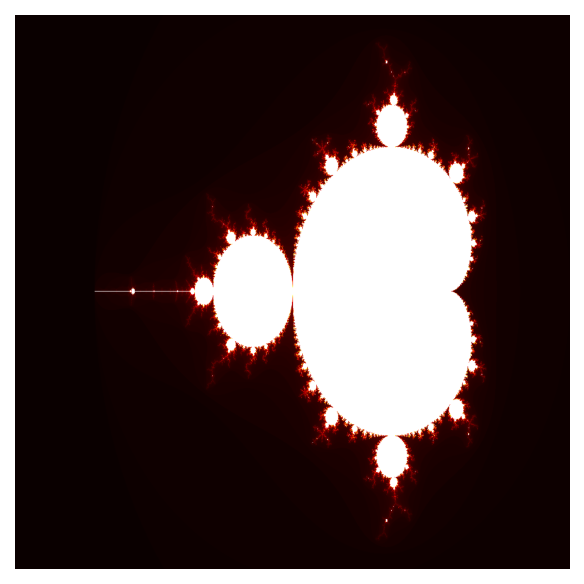

In [7]:
display(Image("mandelbrot_gpu.png"))

### 3.2 Float32 vs float64 (L10-M2)

Since the M4 GPU does not support fp64 in OpenCL, the comparison is GPU f32 against the Numba f64 CPU timing measured by `benchmark.py`.

In [8]:
t_gpu_f32   = 0.0029
t_numba_f64 = 0.0417   # Numba serial complex128 (f64), N=1024, max_iter=100

print(f"GPU f32        : {t_gpu_f32*1e3:6.2f} ms  (max_iter=200)")
print(f"Numba f64 (CPU): {t_numba_f64*1e3:6.2f} ms  (max_iter=100)")
print()
print(f"GPU f32 vs Numba f64 : {t_numba_f64 / t_gpu_f32:5.1f}x faster")
print("Note: GPU did 2x more iterations than Numba, so the real GPU advantage")
print("on equal max_iter would be larger (roughly 2x of the figure above).")


GPU f32        :   2.90 ms  (max_iter=200)
Numba f64 (CPU):  41.70 ms  (max_iter=100)

GPU f32 vs Numba f64 :  14.4x faster
Note: GPU did 2x more iterations than Numba, so the real GPU advantage
on equal max_iter would be larger (roughly 2x of the figure above).


### 3.3 Combined benchmark (L10-M3)
Bar chart with all implementations on a log y axis. Dask cluster is starred because it was measured at N=4096 on a Strato VM, so the bar is here for reference rather than as an apples to apples comparison.

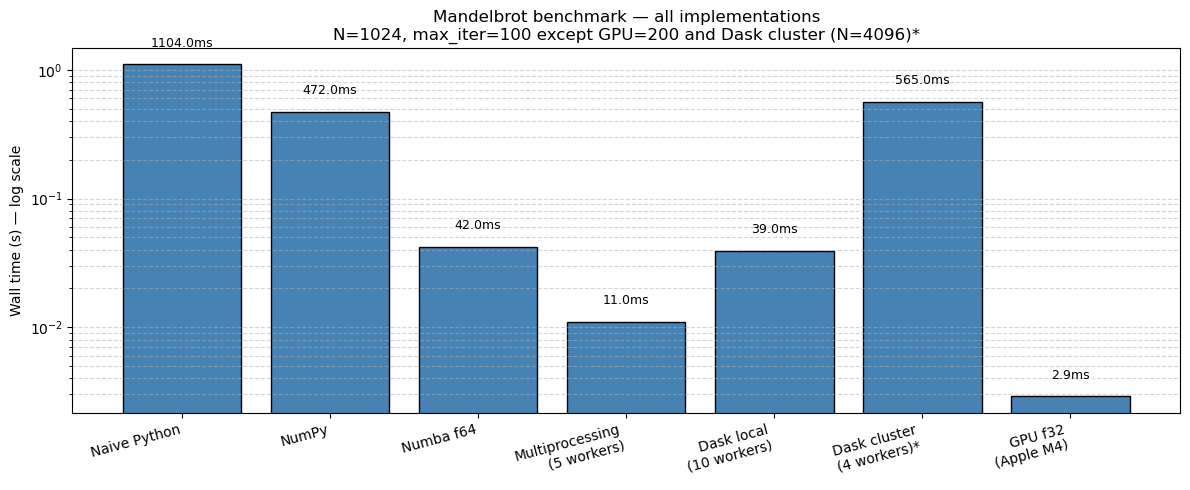

                Implementation |  time (ms) |  speedup vs Numba
-----------------------------------------------------------------
                  Naive Python |     1104.0 |             0.04x
                         NumPy |      472.0 |             0.09x
                     Numba f64 |       42.0 |             1.00x
   Multiprocessing (5 workers) |       11.0 |             3.82x
       Dask local (10 workers) |       39.0 |             1.08x
     Dask cluster (4 workers)* |      565.0 |             0.07x
            GPU f32 (Apple M4) |        2.9 |            14.48x

* Dask cluster measured at N=4096 on Strato VM so not directly comparable.


In [9]:
# Combined benchmark all implementations at the same grid (N=1024) where

results = {
    "Naive Python":                  1.104,    # benchmark.py
    "NumPy":                         0.472,    # benchmark.py
    "Numba f64":                     0.042,    # benchmark.py
    "Multiprocessing\n(5 workers)":  0.011,    # MP2, N=1024
    "Dask local\n(10 workers)":      0.039,    # MP2, N=1024
    "Dask cluster\n(4 workers)*":    0.565,    # MP2, N=4096 on Strato
    "GPU f32\n(Apple M4)":           0.0029,   # mandelbrot_gpu.py, max_iter=200
}

names, times = zip(*results.items())

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, times, log=True, color="steelblue", edgecolor="black")

for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.3,
            f"{t*1e3:.1f}ms", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Wall time (s) — log scale")
ax.set_title("Mandelbrot benchmark — all implementations\n"
             "N=1024, max_iter=100 except GPU=200 and Dask cluster (N=4096)*")
ax.grid(axis="y", which="both", linestyle="--", alpha=0.5)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("benchmark_mp3.png", dpi=150)
plt.show()

# speedup table vs Numba (the closest proxy we have to MP3's "Numba f32" baseline).
t_ref = results["Numba f64"]
print(f"{'Implementation':>30} | {'time (ms)':>10} | {'speedup vs Numba':>17}")
print("-" * 65)
for name, t in results.items():
    label = name.replace("\n", " ")
    print(f"{label:>30} | {t*1e3:>10.1f} | {t_ref/t:>16.2f}x")

print("\n* Dask cluster measured at N=4096 on Strato VM so not directly comparable.")


### 3.4 Where does the GPU sit, and what was surprising

On the same N=1024 problem, the speedup runs:

Naive Python (1104 ms) -> NumPy (472 ms, ~2.3x) -> Numba f64 (42 ms, ~26x vs naive) -> Multiprocessing 5 workers (11 ms, ~100x vs naive) -> GPU f32 (2.9 ms, **~380x vs naive, ~14x vs Numba f64**).

The GPU sits at the top, but the surprise is how small the gap is in absolute terms: 11 ms multiprocessing against 2.9 ms GPU. Multiprocessing is already saturating the M4's CPU side at this resolution, and the GPU only buys back another ~4x on top and that's while the GPU is doing twice the iterations (max_iter=200 vs 100), so on equal terms the GPU lead would be roughly 7-8x over multiprocessing.

The other surprise is Dask local at 39 ms slower than single core Numba at this size. Scheduling overhead per chunk is comparable to the work in the chunk; Dask only starts to win at N=4096. The cleanest takeaway from the chart is that picking the right tool for the problem size matters as much as raw FLOPs: Numba is almost free for small grids, multiprocessing is the easy win once you have CPUs to spare, and the GPU only earns its complexity at problem sizes where the kernel runtime dwarfs the H2D / D2H transfer.

---
## Performance Table

In [10]:

t_numba_1024  = 0.042    # benchmark.py, Numba f64 @ N=1024, max_iter=100
t_numba_4096  = 0.551    # MP2, Numba serial @ N=4096, max_iter=100 (Mac)
t_numba_vm    = 1.274    # MP2, Numba serial on Strato head node @ N=4096

rows = [
    # (impl,                   resolution, runtime,  baseline)
    ("Naive Python",           "1024x1024", 1.104,   t_numba_1024),
    ("NumPy vectorised",       "1024x1024", 0.472,   t_numba_1024),
    ("Numba f64",              "1024x1024", 0.042,   t_numba_1024),
    ("Numba f64",              "4096x4096", 0.551,   t_numba_4096),
    ("Multiprocessing (5w)",   "1024x1024", 0.011,   t_numba_1024),
    ("Dask local (10w)",       "1024x1024", 0.039,   t_numba_1024),
    ("Dask local (10w)",       "4096x4096", 0.213,   t_numba_4096),
    ("Dask cluster (4w)",      "4096x4096", 0.565,   t_numba_vm),
    ("GPU f32 (Apple M4)",     "1024x1024", 0.0029,  t_numba_1024),
]

print(f"{'Implementation':<25} | {'Resolution':>11} | {'Runtime (s)':>11} | {'Speedup vs Numba':>17}")
print("-" * 76)
for impl, res, rt, ref in rows:
    speedup = ref / rt
    print(f"{impl:<25} | {res:>11} | {rt:>11.4f} | {speedup:>16.2f}x")

print()
print("Notes:")
print("- Naive/NumPy/Numba runtimes from benchmark.py (max_iter=100).")
print("- Multiprocessing/Dask local/Dask cluster runtimes from MP2 sweeps (max_iter=100).")
print("- Dask cluster speedup uses Numba serial measured ON the Strato VM (1.274s),")
print("  not the Mac, since the hardware differs.")
print("- GPU f32 runtime is for max_iter=200 (kernel default); CPU rows used max_iter=100.")
print("  On equal max_iter the GPU advantage would be ~2x larger than shown.")
print("- GPU f64 row omitted: Apple M4 OpenCL does not expose cl_khr_fp64.")


Implementation            |  Resolution | Runtime (s) |  Speedup vs Numba
----------------------------------------------------------------------------
Naive Python              |   1024x1024 |      1.1040 |             0.04x
NumPy vectorised          |   1024x1024 |      0.4720 |             0.09x
Numba f64                 |   1024x1024 |      0.0420 |             1.00x
Numba f64                 |   4096x4096 |      0.5510 |             1.00x
Multiprocessing (5w)      |   1024x1024 |      0.0110 |             3.82x
Dask local (10w)          |   1024x1024 |      0.0390 |             1.08x
Dask local (10w)          |   4096x4096 |      0.2130 |             2.59x
Dask cluster (4w)         |   4096x4096 |      0.5650 |             2.25x
GPU f32 (Apple M4)        |   1024x1024 |      0.0029 |            14.48x

Notes:
- Naive/NumPy/Numba runtimes from benchmark.py (max_iter=100).
- Multiprocessing/Dask local/Dask cluster runtimes from MP2 sweeps (max_iter=100).
- Dask cluster speedup uses N